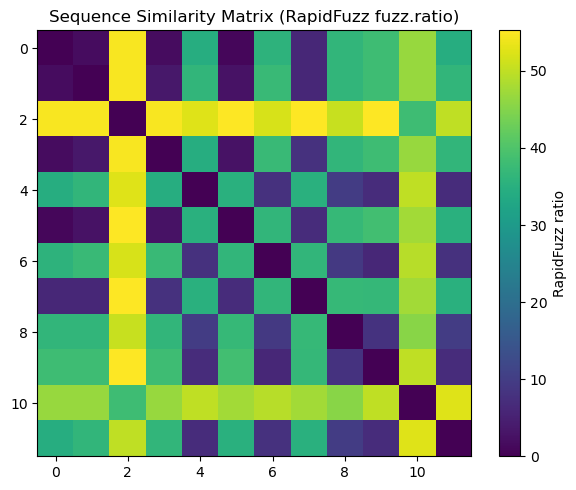

In [13]:
import random
import numpy as np
import matplotlib.pyplot as plt
from rapidfuzz import fuzz

# --- mutation util ---
def mutate_sequence(seq, error_rate=0.05):
    if error_rate <= 0:
        return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5:
                new_seq.append(random.choice("ACGT"))
            elif r < 0.75:
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else:
                pass
        else:
            new_seq.append(base)
    return "".join(new_seq)

# --- base sequences ---
seqs = [
    'ACGACTAGCAACATCGACGACTAGCACTGACTAGCACTATAGAGGGGGAGAGAAAA',
    'ACTATTACGCGCGACCGACGCCTCTAGAGAGAGAAAAGGAGCGCGCACGCGACGGG',
    'ACGGGAATTCCAGACGGGCAGATTTTTTTAGATTTGAGAAGGGGTTTTTTTT',
    'CTCGGCAGGACGAAAACGC',
    'ACTACATTTAGCTGACGACGACG'
]

# --- generate set (15 seqs total) ---
all_seqs = (
    [mutate_sequence(seqs[0]) for _ in range(5)]
    + [mutate_sequence(seqs[1]) for _ in range(5)]
    + [mutate_sequence(seqs[2]) for _ in range(0)]
    + [seqs[3]]
    + [seqs[4]]
)

# --- randomise the order ---
random.shuffle(all_seqs)

# --- compute fuzz.ratio distance matrix ---
n = len(all_seqs)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = 100-fuzz.ratio(all_seqs[i], all_seqs[j])

# --- visualise distance matrix ---
plt.figure(figsize=(6, 5))
plt.imshow(dist_matrix, aspect='auto')
plt.colorbar(label="RapidFuzz ratio")
plt.title("Sequence Similarity Matrix (RapidFuzz fuzz.ratio)")
plt.tight_layout()
plt.show()


In [15]:
from sklearn.cluster import AgglomerativeClustering

clust = AgglomerativeClustering(
    metric="precomputed",
    linkage="single",
    distance_threshold=15,  # example threshold
    n_clusters=None
)

labels = clust.fit_predict(dist_matrix)
print(labels)

[1 1 2 1 0 1 0 1 0 0 3 0]
